In [51]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import zscore
import scipy.stats as stats

import numpy as np

In [52]:
df = pd.read_csv("kidney_disease_model_ready.csv")
col={'age': 'age',
     'bp': 'blood_pressure',
     'sg': 'specific_gravity',
     'al': 'albumin',
     'su': 'sugar',
     'rbc': 'red_blood_cells',
     'pc': 'pus_cell',
     'pcc': 'pus_cell_clumps',
     'ba': 'bacteria',
     'bgr': 'blood_glucose_random',
     'bu': 'blood_urea',
     'sc': 'serum_creatinine',
     'sod': 'sodium',
     'pot': 'potassium',
     'hemo': 'hemoglobin',
     'pcv': 'packed_cell_volume',
     'wc': 'white_blood_cell_count',
     'rc': 'red_blood_cell_count',
     'htn': 'hypertension',
     'dm': 'diabetes_mellitus',
     'cad': 'coronary_artery_disease',
     'appet': 'appetite',
     'pe': 'pedal_edema',
     'ane': 'anemia',
     'classification': 'class'}
df.rename(columns=col, inplace=True)
df

,id,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,...,pc_normal,pcc_present,ba_present,htn_yes,dm_yes,cad_yes,appet_poor,pe_yes,ane_yes,classification_notckd
0,3,48.000000,70.000000,1.005000,4.000000,0.000000,117.000000,56.000000,3.800000,111.000000,...,0,1,0,1,0,0,1,1,1,0
1,9,53.000000,90.000000,1.020000,2.000000,0.000000,70.000000,107.000000,7.200000,114.000000,...,0,1,0,1,1,0,1,0,1,0
2,11,63.000000,70.000000,1.010000,3.000000,0.000000,380.000000,60.000000,2.700000,131.000000,...,0,1,0,1,1,0,1,1,0,0
3,14,68.000000,80.000000,1.010000,3.000000,2.000000,157.000000,90.000000,4.100000,130.000000,...,0,1,1,1,1,1,1,1,0,0
4,20,61.000000,80.000000,1.015000,2.000000,0.000000,173.000000,148.000000,3.900000,135.000000,...,0,0,0,1,1,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,395,55.000000,80.000000,1.020000,0.000000,0.000000,140.000000,49.000000,0.500000,150.000000,...,1,0,0,0,0,0,0,0,0,1
154,396,42.000000,70.000000,1.025000,0.000000,0.000000,75.000000,31.000000,1.200000,141.000000,...,1,0,0,0,0,0,0,0,0,1
155,397,12.000000,80.000000,1.020000,0.000000,0.000000,100.000000,26.000000,0.600000,137.000000,...,1,0,0,0,0,0,0,0,0,1
156,398,17.000000,60.000000,1.025000,0.000000,0.000000,114.000000,50.000000,1.000000,135.000000,...,1,0,0,0,0,0,0,0,0,1


EDA: Target Distribution

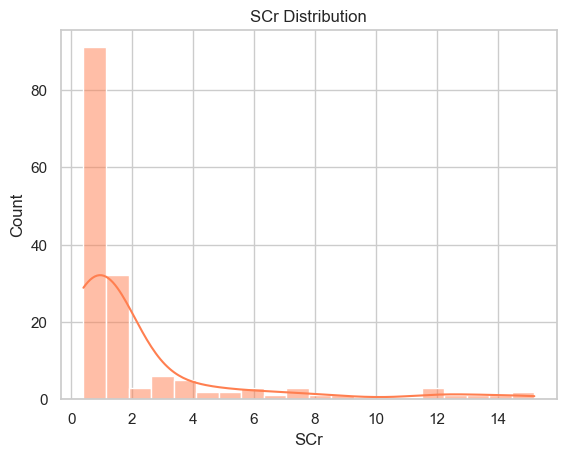

In [53]:
target = "serum_creatinine"
sns.histplot(df[target], kde=True, bins=20, color='coral')
plt.title("SCr Distribution")
plt.xlabel("SCr")
plt.ylabel("Count")
plt.show()

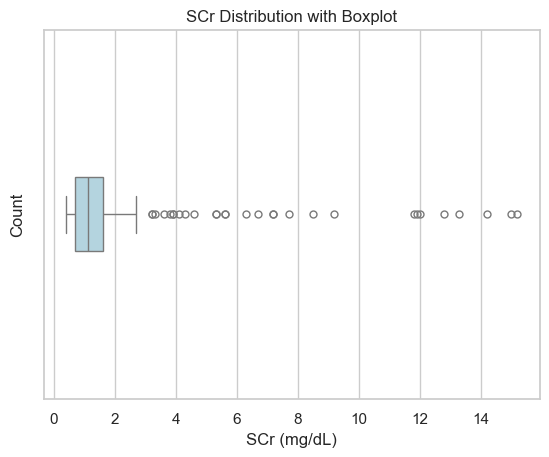

In [54]:
target = "serum_creatinine"
sns.boxplot(x=df[target], width=0.2, color='lightblue', fliersize=5)
plt.title("SCr Distribution with Boxplot")
plt.xlabel("SCr (mg/dL)")
plt.ylabel("Count")
plt.show()




Predictor Descriptions

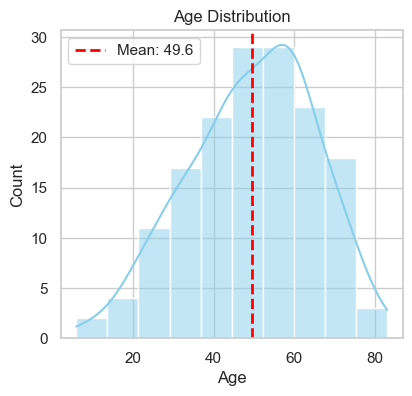

In [55]:
sns.set(style="whitegrid")

plt.figure(figsize=(15, 4))


plt.subplot(1, 3, 1)
sns.histplot(df['age'], bins=10, kde=True, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

mean_age = df['age'].mean()
plt.axvline(mean_age, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_age:.1f}')
plt.legend()


/var/folders/qg/fq9xw4y90wb1czds20rzth_c0000gn/T/ipykernel_2474/2117319305.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


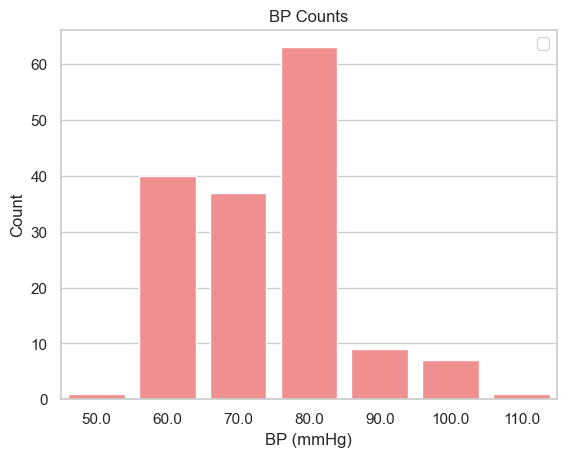

In [56]:
sns.countplot(x='blood_pressure', data=df, color='#FF7F7F', order=sorted(df['blood_pressure'].unique()))
mean_bp = df['blood_pressure'].mean()
plt.title('BP Counts')
plt.xlabel('BP (mmHg)')
plt.ylabel('Count')
plt.legend()


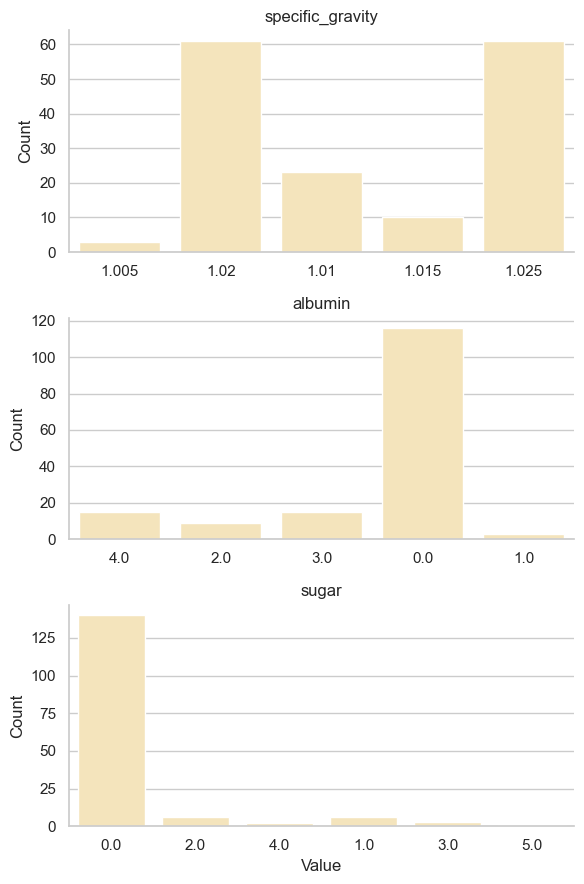

In [57]:
urine_cols = ['specific_gravity', 'albumin', 'sugar']
urine_melted = df[urine_cols].melt(var_name='Marker', value_name='Value')
urine_melted['Value'] = urine_melted['Value'].astype(str)
g = sns.FacetGrid(urine_melted, row='Marker', sharex=False, sharey=False, height=3, aspect=2)
g.map_dataframe(sns.countplot, x='Value', color="#FDE8B3")
g.set_axis_labels("Value", "Count")
g.set_titles("{row_name}")  
plt.tight_layout()
plt.show()


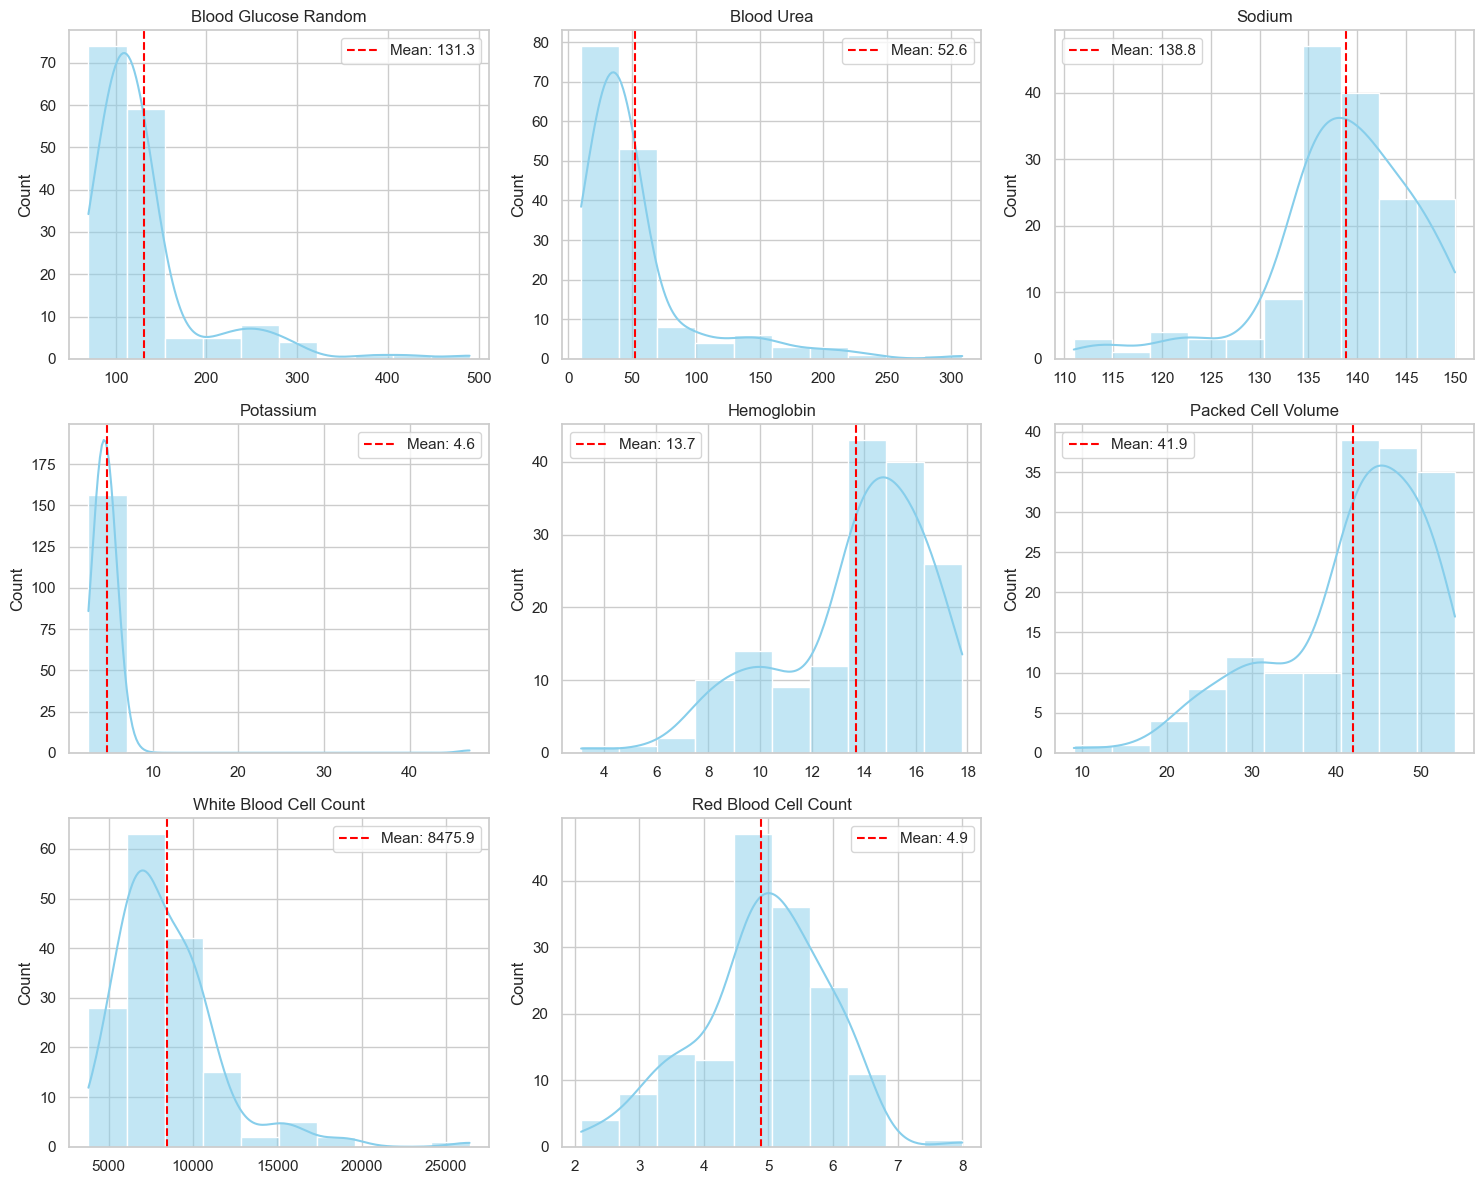

In [58]:
sns.set(style="whitegrid")

blood_cols = ['blood_glucose_random', 'blood_urea', 
              'sodium', 'potassium', 'hemoglobin', 'packed_cell_volume', 
              'white_blood_cell_count', 'red_blood_cell_count']

plt.figure(figsize=(15, 12))
for i, col in enumerate(blood_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], bins=10, kde=True, color='#87CEEB')
    mean_val = df[col].mean()
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    plt.title(col.replace('_',' ').title())
    plt.xlabel('')
    plt.ylabel('Count')
    plt.legend()
plt.tight_layout()
plt.show()


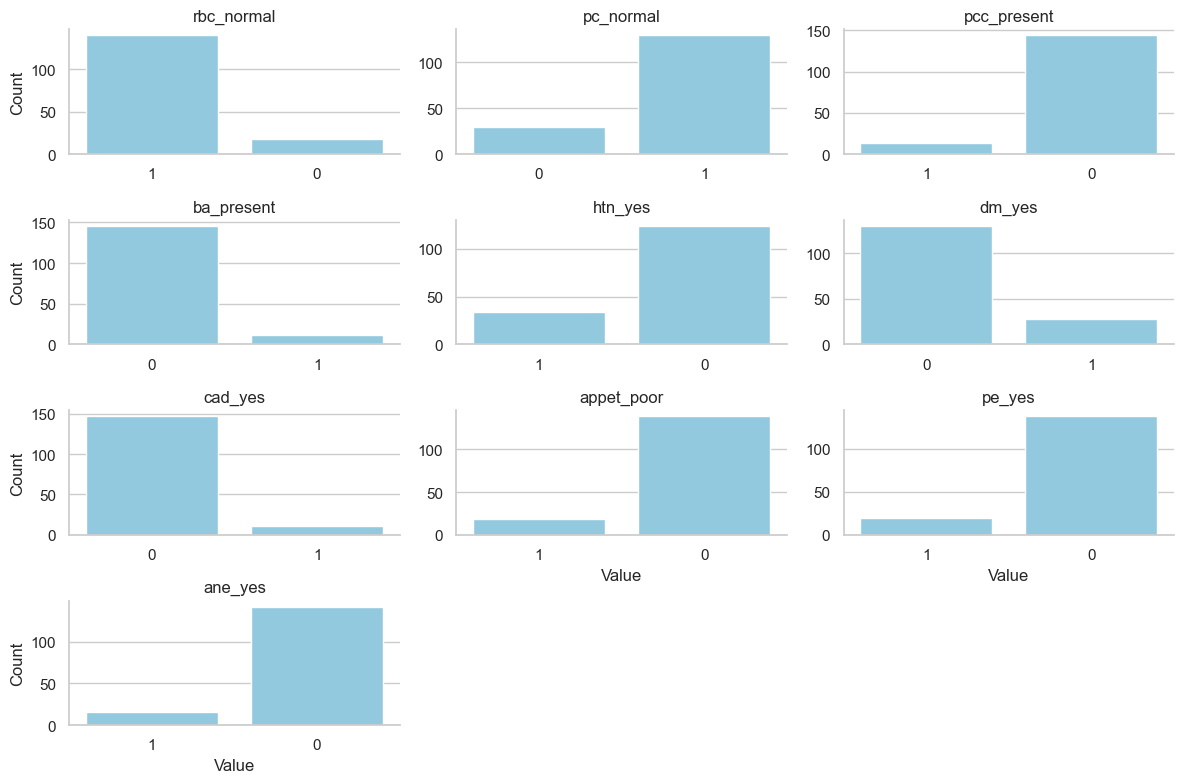

In [59]:
binary_melted = df[binary_cols].melt(var_name='Indicator', value_name='Value')
binary_melted['Value'] = binary_melted['Value'].astype(str) 

g = sns.FacetGrid(binary_melted, col='Indicator', col_wrap=3, sharex=False, sharey=False, height=2, aspect=2)
g.map_dataframe(sns.countplot, x='Value', color="#87CEEB") 
g.set_axis_labels("Value", "Count")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

serum_creatinine          1.000000
blood_urea                0.896094
albumin                   0.702889
ane_yes                   0.663212
htn_yes                   0.659078
pe_yes                    0.623109
dm_yes                    0.567390
appet_poor                0.510699
blood_pressure            0.386551
pcc_present               0.361965
sugar                     0.347196
blood_glucose_random      0.331284
cad_yes                   0.321205
ba_present                0.229238
age                       0.189721
potassium                 0.141896
white_blood_cell_count    0.123953
rbc_normal               -0.410408
sodium                   -0.532575
specific_gravity         -0.563122
pc_normal                -0.588517
red_blood_cell_count     -0.639021
hemoglobin               -0.723937
packed_cell_volume       -0.726187
Name: serum_creatinine, dtype: float64


/var/folders/qg/fq9xw4y90wb1czds20rzth_c0000gn/T/ipykernel_2474/2353695809.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Correlation', y='Predictor', data=target_corr_df,  palette='coolwarm')


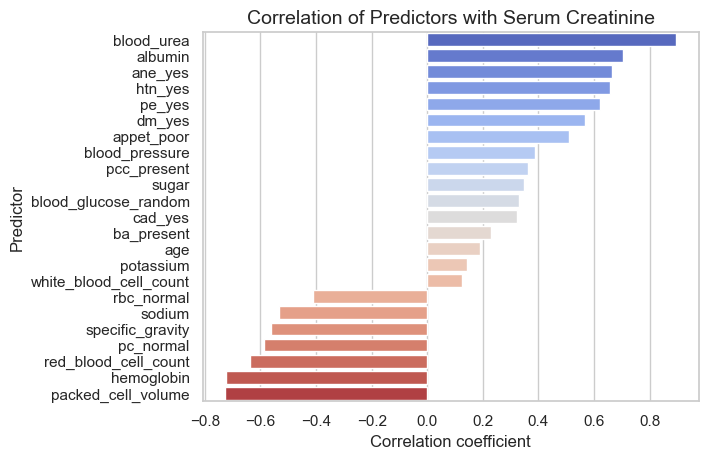

In [60]:
exclude = ['id', 'classification_notckd']
use_col = df.drop(columns = exclude).select_dtypes(include='number').columns
full_corr_matrix = df[use_col].corr()
target_corr = full_corr_matrix['serum_creatinine'].sort_values(ascending=False)
print(target_corr)
target_corr = target_corr.drop('serum_creatinine')
target_corr_df = target_corr.reset_index()
target_corr_df.columns = ['Predictor', 'Correlation']
sns.barplot(x='Correlation', y='Predictor', data=target_corr_df,  palette='coolwarm')
plt.title('Correlation of Predictors with Serum Creatinine', fontsize=14)
plt.xlabel('Correlation coefficient')
plt.ylabel('Predictor')
plt.show()


Predictor Relationship with Target

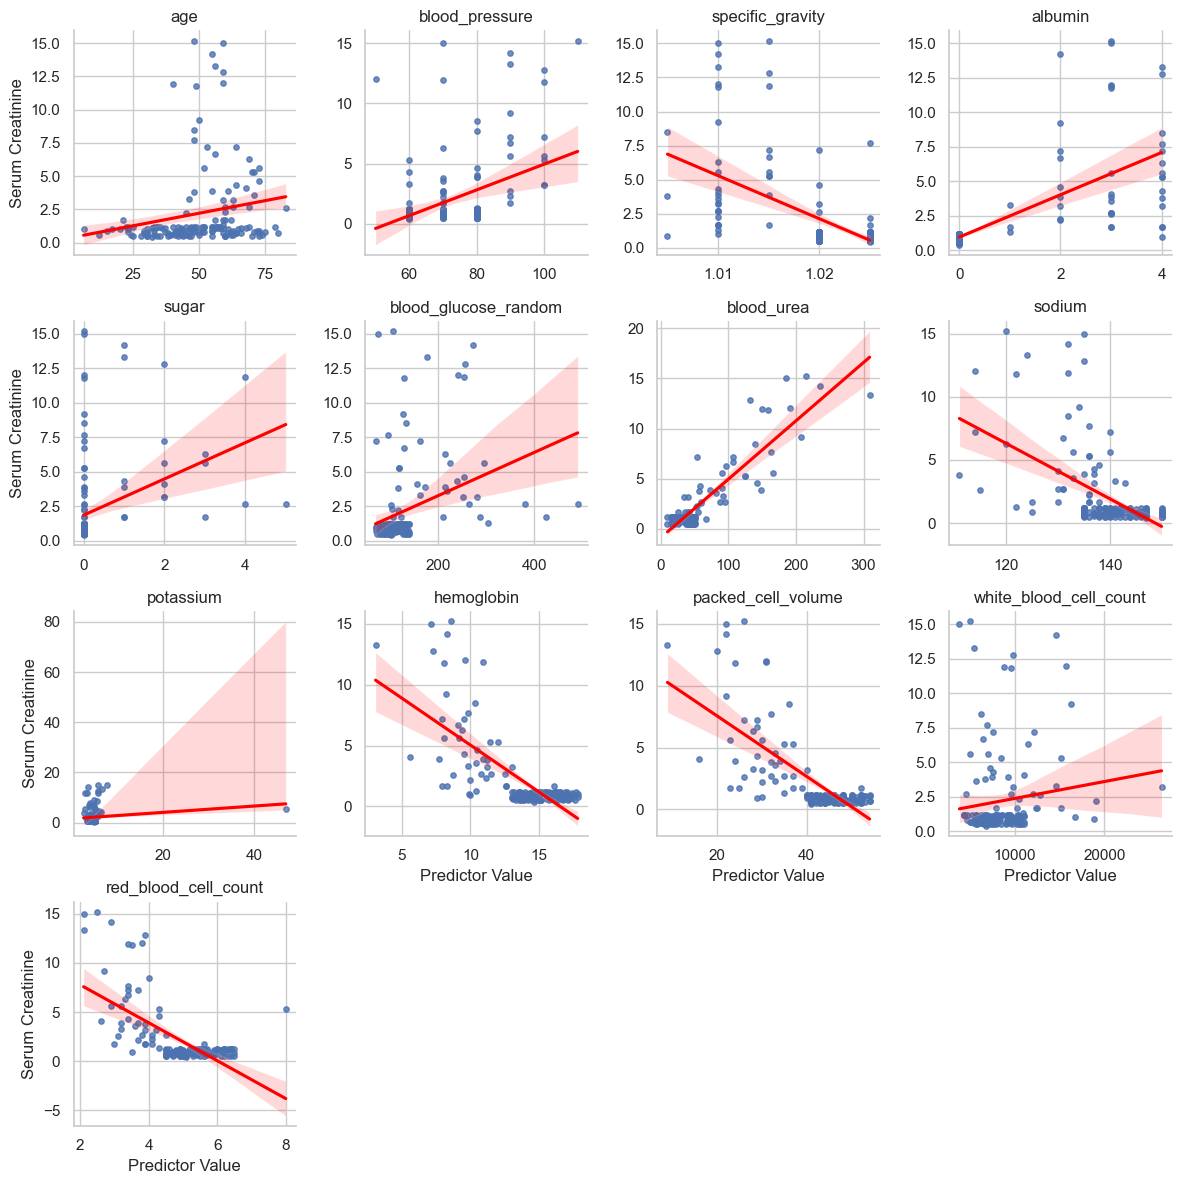

In [61]:
numeric_vars = ['age',
    'blood_pressure',
    'specific_gravity',
    'albumin',
    'sugar',
    'blood_glucose_random',
    'blood_urea',
    'sodium',
    'potassium',
    'hemoglobin',
    'packed_cell_volume',
    'white_blood_cell_count',
    'red_blood_cell_count']
binary_cols = [
    'rbc_normal',
    'pc_normal',
    'pcc_present',
    'ba_present',
    'htn_yes',
    'dm_yes',           
    'cad_yes',
    'appet_poor',    
    'pe_yes',
    'ane_yes'
]

df_melted = df.melt(id_vars='serum_creatinine', value_vars=numeric_vars,
                    var_name='Predictor', value_name='Value')
g = sns.FacetGrid(df_melted, col='Predictor', col_wrap=4, sharex=False, sharey=False, height=3)
g.map_dataframe(sns.regplot, x='Value', y='serum_creatinine', scatter_kws={'s':15}, line_kws={'color':'red'})
g.set_axis_labels("Predictor Value", "Serum Creatinine")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

/Users/sushmakulkarni/Desktop/Stats_project/.venv/lib/python3.10/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


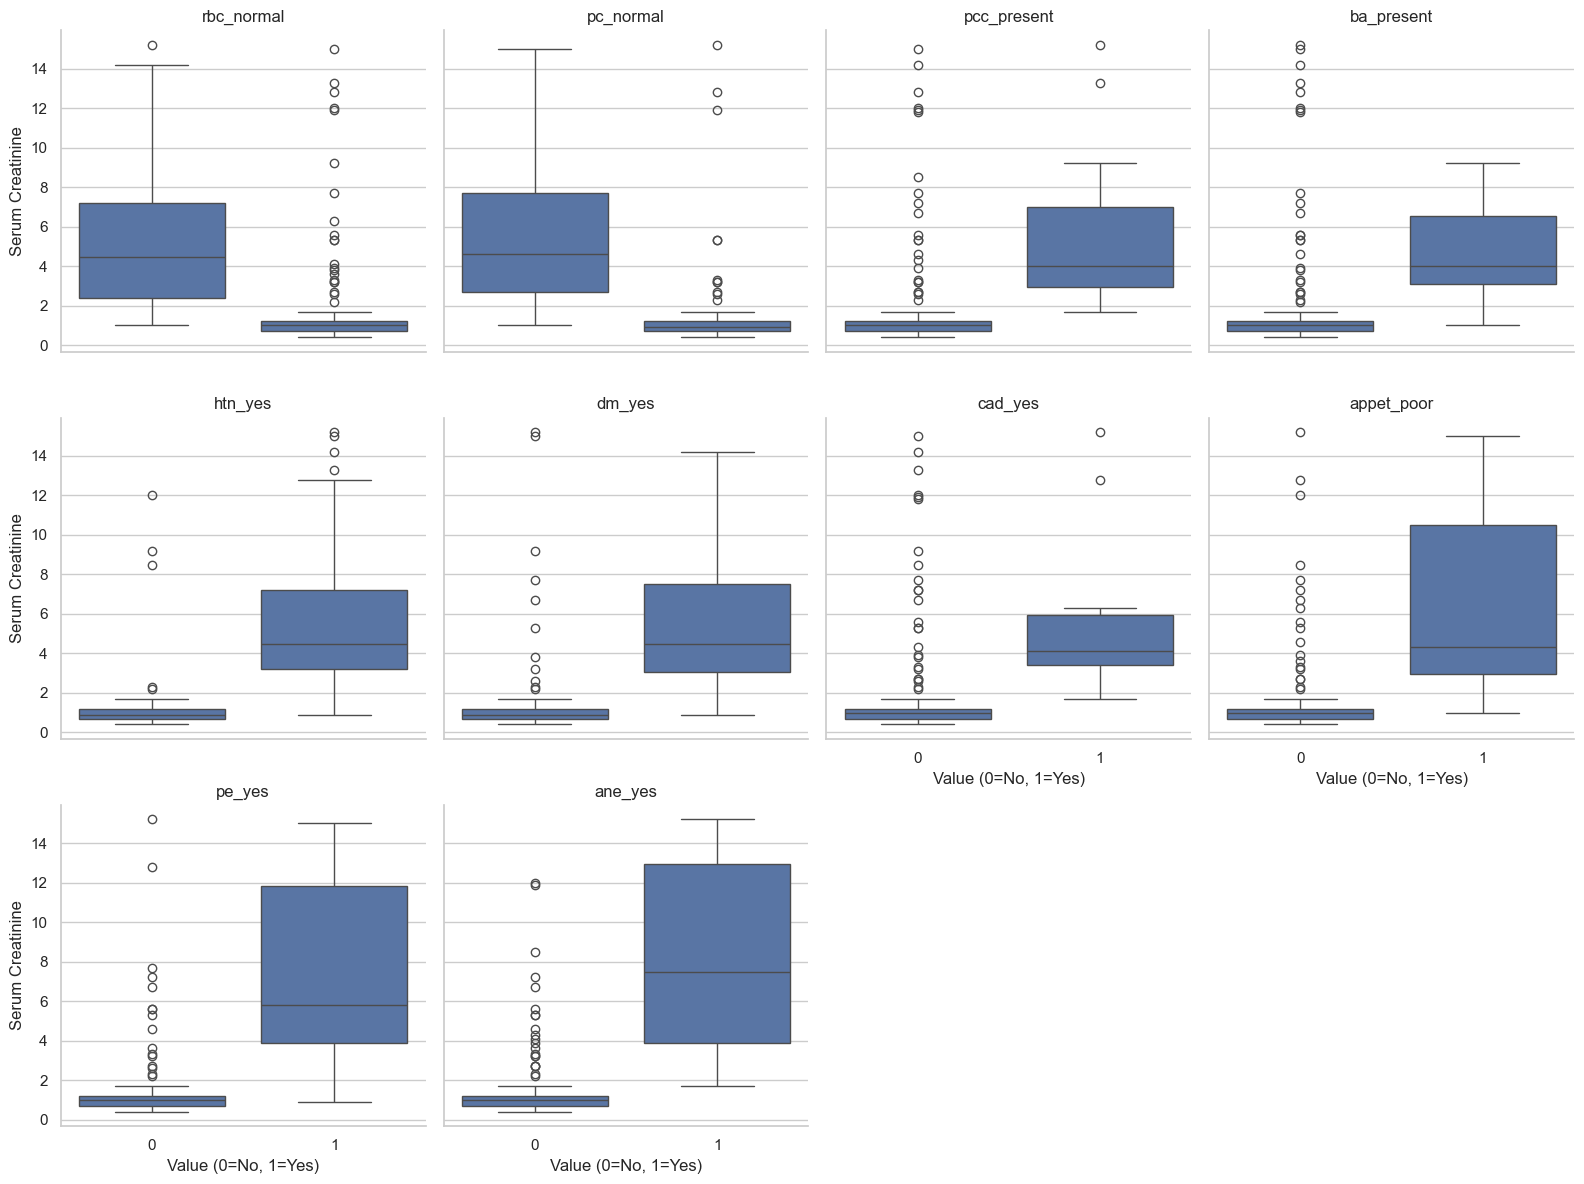

In [62]:
df_binary = df[binary_cols + ['serum_creatinine']].melt(  id_vars='serum_creatinine', value_vars=binary_cols, 
    var_name='Predictor', 
    value_name='Value')
g = sns.FacetGrid(df_binary, col='Predictor', col_wrap=4, sharey=True, height=4)
g.map(sns.boxplot, 'Value', 'serum_creatinine')
g.set_axis_labels("Value (0=No, 1=Yes)", "Serum Creatinine")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

Correlation HeatMaps 

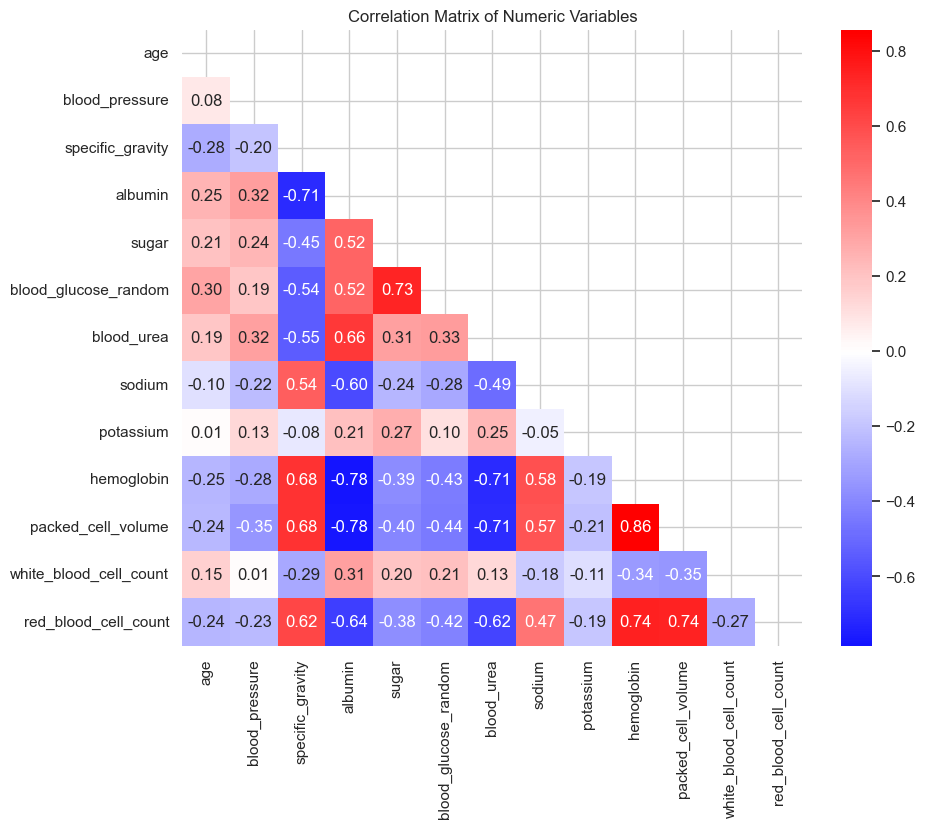

In [63]:
continuous_vars = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 
                   'sugar', 'blood_glucose_random', 'blood_urea', 'sodium', 
                   'potassium', 'hemoglobin', 'packed_cell_volume', 
                   'white_blood_cell_count', 'red_blood_cell_count']

corr = df[continuous_vars].corr()

plt.figure(figsize=(10,8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # mask upper triangle
sns.heatmap(corr, annot=True, fmt=".2f", cmap="bwr", mask=mask, center=0)
plt.title("Correlation Matrix of Numeric Variables")
sns.set_style("whitegrid")
plt.show()


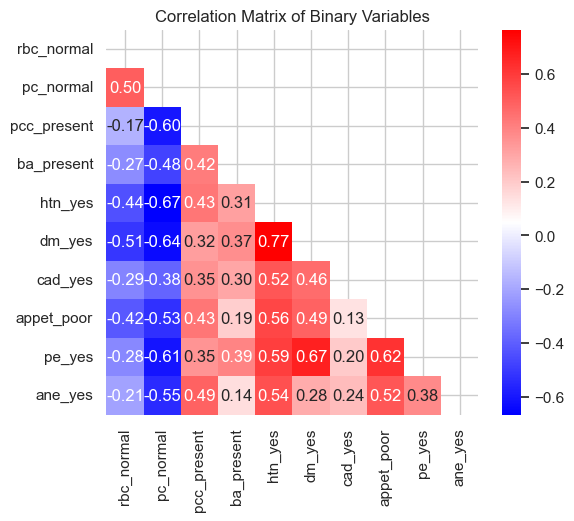

In [64]:
corr_bin = df[binary_cols].corr()
mask = np.triu(np.ones_like(corr_bin, dtype=bool))  

plt.figure(figsize=(6,5))
sns.heatmap(corr_bin, annot=True, fmt=".2f", cmap="bwr", mask=mask)
plt.title("Correlation Matrix of Binary Variables")
plt.show()

FULL MODEL

In [65]:
import statsmodels.api as sm
y = df['serum_creatinine']
X = df.drop(columns=['serum_creatinine', 'classification_notckd', 'id'])  # drop target, ID, and other irrelevant columns
X_full = X
X_const = sm.add_constant(X)
full_model = sm.OLS(y, X_const).fit()
print(full_model.summary())


                            OLS Regression Results                            
Dep. Variable:       serum_creatinine   R-squared:                       0.876
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                     41.11
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           1.46e-49
Time:                        23:31:16   Log-Likelihood:                -236.48
No. Observations:                 158   AIC:                             521.0
Df Residuals:                     134   BIC:                             594.5
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    -10

In [66]:
pd.set_option('display.float_format', lambda x: f'{x:.6f}')

pvals_all_sorted = full_model.pvalues.sort_values()


pvals_numbered = pvals_all_sorted.reset_index()
pvals_numbered.index = pvals_numbered.index + 1
pvals_numbered.columns = ["feature", "p_value"]

print(pvals_numbered.to_string(index=True, float_format=lambda x: f'{x:.6f}'))

                   feature  p_value
1               blood_urea 0.000000
2                potassium 0.000673
3                  albumin 0.004637
4                   pe_yes 0.006225
5   white_blood_cell_count 0.007801
6                  ane_yes 0.035166
7                pc_normal 0.040628
8               appet_poor 0.061572
9           blood_pressure 0.065111
10              ba_present 0.083435
11    red_blood_cell_count 0.131206
12      packed_cell_volume 0.171352
13              rbc_normal 0.224490
14                   sugar 0.252530
15              hemoglobin 0.263943
16             pcc_present 0.341343
17    blood_glucose_random 0.439172
18                 htn_yes 0.634915
19        specific_gravity 0.648456
20                     age 0.662654
21                   const 0.723495
22                 cad_yes 0.778708
23                  sodium 0.977711
24                  dm_yes 0.992364


In [67]:
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                       for i in range(len(X.columns))]
    return vif_data.sort_values('VIF', ascending=False)


print("INITIAL VIF (FULL MODEL)")

vif_initial = calculate_vif(X)
print(vif_initial)


INITIAL VIF (FULL MODEL)
                  Variable         VIF
2         specific_gravity 1063.873582
7                   sodium  734.957014
9               hemoglobin  127.639386
10      packed_cell_volume  122.161878
12    red_blood_cell_count   69.607997
1           blood_pressure   65.841442
14               pc_normal   22.772534
13              rbc_normal   20.477171
5     blood_glucose_random   17.552844
0                      age   14.249877
11  white_blood_cell_count   12.453238
3                  albumin    7.516191
17                 htn_yes    7.260139
6               blood_urea    7.103155
18                  dm_yes    6.212236
8                potassium    4.520094
21                  pe_yes    4.036256
4                    sugar    3.767828
22                 ane_yes    3.727296
20              appet_poor    3.120850
15             pcc_present    2.575665
16              ba_present    2.234367
19                 cad_yes    2.070195


HANDLING VIF Multicollinearity and Backword Elimination to get our predictors

In [68]:
def compute_vif(X):
    vif_df = pd.DataFrame()
    vif_df["feature"] = X.columns
    vif_df["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
    return vif_df


def backward_elimination_with_vif(X, y, alpha=0.05, vif_thresh=10, verbose=False):
    """
    Combined backward elimination + VIF constraint.
    Removes predictor with:
        1) VIF > vif_thresh (highest VIF goes first)
        2) otherwise: highest p-value > alpha
    Continues until both p-values and VIFs meet criteria.
    """
    X_current = X.copy()
    removed = []
    step = 0

    while True:
        X_const = sm.add_constant(X_current)
        model = sm.OLS(y, X_const).fit()
        vif_df = compute_vif(X_current)
        high_vif = vif_df[vif_df["VIF"] > vif_thresh]

        if not high_vif.empty:
            worst_row = high_vif.sort_values("VIF", ascending=False).iloc[0]
            worst_var = worst_row["feature"]
            worst_vif = worst_row["VIF"]

            removed.append((worst_var, f"VIF={worst_vif:.2f}"))
            if verbose:
                print(f"Step {step}: Removing '{worst_var}' due to HIGH VIF = {worst_vif:.2f}")

            X_current = X_current.drop(columns=[worst_var])
            step += 1
            continue
        pvals = model.pvalues.drop("const")
        worst_p = pvals.max()
        worst_p_var = pvals.idxmax()

        if worst_p < alpha:
            if verbose:
                print("\nAll predictors meet p-value and VIF criteria.")
            break

        removed.append((worst_p_var, f"p={worst_p:.4f}"))
        if verbose:
            print(f"Step {step}: Removing '{worst_p_var}' due to HIGH p-value = {worst_p:.4f}")

        X_current = X_current.drop(columns=[worst_p_var])
        step += 1

    return removed, list(X_current.columns)

n_runs = 10
alpha = 0.05
vif_thresh = 10

final_sets = []

for r in range(n_runs):
    X_shuffled = X_full.sample(frac=1, axis=1, random_state=r)

    removed_vars, final_vars = backward_elimination_with_vif(
        X_shuffled, y, alpha=alpha, vif_thresh=vif_thresh, verbose=False
    )

    final_sorted = tuple(sorted(final_vars))
    final_sets.append(final_sorted)
    print(f"Run {r}: final predictors ({len(final_vars)} vars) -> {final_sorted}")

unique_final_sets = set(final_sets)
print("\nNumber of unique final predictor sets across runs:", len(unique_final_sets))
for s in unique_final_sets:
    print("  ", s)

full_model = sm.OLS(y, sm.add_constant(X_full)).fit()

pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print("\nFULL MODEL: Coefficients and P-Values (sorted by p-value)\n")

coef_table = pd.DataFrame({
    "feature": full_model.params.index,
    "coefficient": full_model.params.values,
    "p_value": full_model.pvalues.values
})

intercept_row = coef_table[coef_table["feature"] == "const"]
coef_no_const = coef_table[coef_table["feature"] != "const"].copy()
coef_no_const = coef_no_const.sort_values("p_value")

coef_final_table = pd.concat([intercept_row, coef_no_const], ignore_index=True)
coef_final_table.index = coef_final_table.index + 1

print(coef_final_table.to_string(index=True, float_format=lambda x: f'{x:.6f}'))

print("\nVIF for final selected model (last run):")
X_final = X_full[final_vars]  
vif_final = compute_vif(X_final)
print(vif_final)

Run 0: final predictors (7 vars) -> ('albumin', 'ane_yes', 'blood_urea', 'pcc_present', 'pe_yes', 'potassium', 'white_blood_cell_count')
Run 1: final predictors (7 vars) -> ('albumin', 'ane_yes', 'blood_urea', 'pcc_present', 'pe_yes', 'potassium', 'white_blood_cell_count')
Run 2: final predictors (7 vars) -> ('albumin', 'ane_yes', 'blood_urea', 'pcc_present', 'pe_yes', 'potassium', 'white_blood_cell_count')
Run 3: final predictors (7 vars) -> ('albumin', 'ane_yes', 'blood_urea', 'pcc_present', 'pe_yes', 'potassium', 'white_blood_cell_count')
Run 4: final predictors (7 vars) -> ('albumin', 'ane_yes', 'blood_urea', 'pcc_present', 'pe_yes', 'potassium', 'white_blood_cell_count')
Run 5: final predictors (7 vars) -> ('albumin', 'ane_yes', 'blood_urea', 'pcc_present', 'pe_yes', 'potassium', 'white_blood_cell_count')
Run 6: final predictors (7 vars) -> ('albumin', 'ane_yes', 'blood_urea', 'pcc_present', 'pe_yes', 'potassium', 'white_blood_cell_count')
Run 7: final predictors (7 vars) -> ('alb

REDUCED MODEL

final selected model (last run):
                  feature      VIF
0                 albumin 3.270957
1              blood_urea 4.963798
2             pcc_present 1.652715
3  white_blood_cell_count 2.920653
4                 ane_yes 2.225405
5               potassium 2.690243
6                  pe_yes 2.154418

In [69]:
predictors_final = ['albumin', 'ane_yes', 'blood_urea', 'pcc_present', 'pe_yes', 'potassium', 'white_blood_cell_count']

X_reduced = df[predictors_final]
y = df['serum_creatinine']
X_reduced = sm.add_constant(X_reduced)
reduced_model = sm.OLS(y, X_reduced).fit()
print(reduced_model.summary())

                            OLS Regression Results                            
Dep. Variable:       serum_creatinine   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     123.2
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           6.60e-59
Time:                        23:31:17   Log-Likelihood:                -250.45
No. Observations:                 158   AIC:                             516.9
Df Residuals:                     150   BIC:                             541.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

RESIDUALS/ ROBUST SE 

In [70]:

predictors_final = ['albumin', 'ane_yes', 'blood_urea', 
                    'pcc_present', 'pe_yes', 'potassium', 'white_blood_cell_count']

y = df['serum_creatinine']
X_reduced = sm.add_constant(df[predictors_final])

reduced_model = sm.OLS(y, X_reduced).fit()
print(reduced_model.summary())

reduced_model_robust = reduced_model.get_robustcov_results(cov_type='HC3')
print(reduced_model_robust.summary())

print(reduced_model_robust.model.exog_names)


                            OLS Regression Results                            
Dep. Variable:       serum_creatinine   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     123.2
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           6.60e-59
Time:                        23:31:17   Log-Likelihood:                -250.45
No. Observations:                 158   AIC:                             516.9
Df Residuals:                     150   BIC:                             541.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

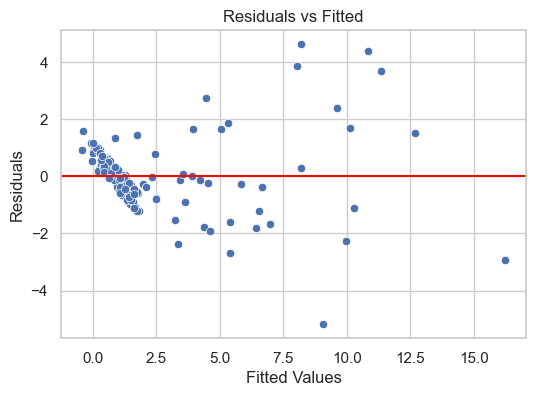

In [71]:
resid = reduced_model_robust.resid
fitted = reduced_model_robust.fittedvalues

plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=resid)
plt.axhline(0, color='red')
plt.title("Residuals vs Fitted")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

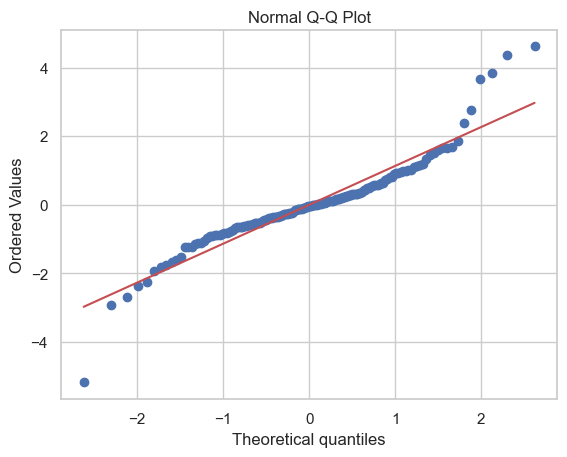

In [72]:
stats.probplot(resid, dist="norm", plot=plt)
plt.title("Normal Q-Q Plot")
plt.show()

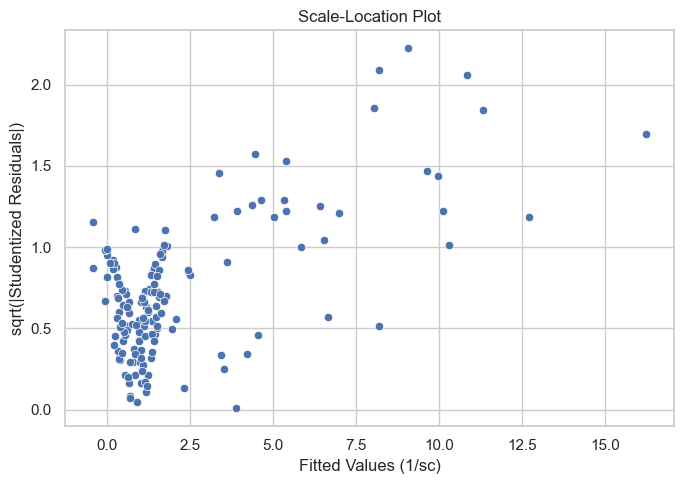

In [73]:
influence = reduced_model.get_influence()
studentized_resid = influence.resid_studentized_external
hat_values = influence.hat_matrix_diag
cooks_d, _ = influence.cooks_distance



plt.figure(figsize=(7,5))
sqrt_abs_sr = np.sqrt(np.abs(studentized_resid))
sns.scatterplot(x=fitted, y=sqrt_abs_sr)
plt.xlabel("Fitted Values (1/sc)")
plt.ylabel("sqrt(|Studentized Residuals|)")
plt.title("Scale-Location Plot")
plt.tight_layout()
plt.show()